## Training LSTM with K-Fold Cross Validation

**Perbedaan dengan notebook original:**
- Tidak ada validation set terpisah (20% val → dialokasikan ke training)
- Split: 80% train + 20% test (bukan 60/20/20)
- Menggunakan K-Fold (5-fold) pada training set untuk mencegah overfitting
- Final model ditraining ulang pada seluruh 80% training data

**Goal:** Test apakah F1 score meningkat dengan lebih banyak training data

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Import model, modelIO
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE
from src.model.lstm_bidirectional import BiLSTMModelGPUOptimized
from src.model.lstm_nested import NestedLSTMModelGPUOptimized
from src.model.lstm_peephole import PeepholeLSTMModelGPUOptimized
from src.model.lstm_cifg import CIFGLSTMModelGPUOptimized
from src.model.lstm_glu import GLULSTMModelGPUOptimized
from src.model.lstm_layernorm import LayerNormLSTMModelGPUOptimized
from src.model.lstm_residual import ResidualLSTMModelGPUOptimized
# Import attention models
from src.model.lstm_attention_optimized import AttentionLSTMModelGPUOptimized
from src.model.lstm_bidirectional_attention import BiDirectionalAttentionLSTMModelGPUOptimized
from src.model.lstm_cifg_attention import CIFGAttentionLSTMModelGPUOptimized
from src.model.lstm_glu_attention import GLUAttentionLSTMModelGPUOptimized
from src.model.lstm_nested_attention import NestedAttentionLSTMModelGPUOptimized
from src.utils.model_io import save_model, load_and_build_model

# Model registry untuk loop experiments
MODEL_REGISTRY = {
    'Attention': AttentionLSTMModelGPUOptimized,
    # 'BiDirectional-Attention': BiDirectionalAttentionLSTMModelGPUOptimized,
}

# Export path
CHECKPOINT_PATH = os.path.join(os.getcwd(), '..', 'src/model/checkpoints/lstm_kfold.pkl')
print(CHECKPOINT_PATH)
print(f"📦 Available models: {list(MODEL_REGISTRY.keys())}")

✅ CuPy detected - Using GPU acceleration
✅ CuPy detected - Using GPU acceleration
c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_kfold.pkl
📦 Available models: ['Attention']


In [2]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [3]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

# ============================================================
# 🎯 FEATURE ENGINEERING - CREATE ALL FEATURES
# ============================================================
print("🔧 Creating ALL features for grid search flexibility...\n")

# === BASE: Temporal Features ===
print("  → Creating temporal features...")
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# === INTERACTION FEATURES (P×I derivatives) ===
print("  → Creating interaction features...")

# TIER 1: Interactions
df['priority_impact_product'] = df['Priority'] * df['Impact']
df['priority_impact_sum'] = df['Priority'] + df['Impact']
df['risk_score'] = (0.6 * df['Priority']) + (0.4 * df['Impact'])

# TIER 2: Polynomial
df['priority_squared'] = df['Priority'] ** 2
df['impact_squared'] = df['Impact'] ** 2

# TIER 3: Temporal interactions
df['priority_hour_interaction'] = df['Priority'] * df['hour']
df['impact_hour_interaction'] = df['Impact'] * df['hour']
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# === SERVICE TYPE FEATURES ===
print("  → Creating service type features...")
service_incident_rates = df.groupby('Service Type')['incident'].mean()
df['service_risk_score'] = df['Service Type'].map(service_incident_rates)
service_freq = df['Service Type'].value_counts(normalize=True)
df['service_frequency'] = df['Service Type'].map(service_freq)
name_incident_rates = df.groupby('Service Name')['incident'].mean()
df['service_name_risk'] = df['Service Name'].map(name_incident_rates)

df['service_risk_score'] = df['service_risk_score'].fillna(df['service_risk_score'].mean())
df['service_frequency'] = df['service_frequency'].fillna(0)
df['service_name_risk'] = df['service_name_risk'].fillna(df['service_name_risk'].mean())

# === SEQUENCE-AWARE FEATURES ===
print("  → Creating sequence-aware features...")
df['priority_volatility'] = df['Priority'].rolling(window=4, min_periods=1).std().fillna(0)
df['impact_volatility'] = df['Impact'].rolling(window=4, min_periods=1).std().fillna(0)
df['priority_volatility'] = df['priority_volatility'].clip(0, 5)
df['impact_volatility'] = df['impact_volatility'].clip(0, 5)
df['priority_change'] = df['Priority'].diff().fillna(0)
df['impact_change'] = df['Impact'].diff().fillna(0)
df['incidents_last_2h'] = df['incident'].rolling(window=4, min_periods=1).sum()
df['time_since_last_incident'] = (~df['incident'].astype(bool)).cumsum()
df.loc[df['incident'] == 1, 'time_since_last_incident'] = 0
df['consecutive_high_priority'] = (df['Priority'] >= 2).rolling(window=6, min_periods=1).sum()
priority_velocity = df['Priority'].diff()
df['priority_acceleration'] = priority_velocity.diff().fillna(0)

print(f"\n✅ All features created!")
print(f"   Dataset shape: {df.shape}")

🔧 Creating ALL features for grid search flexibility...

  → Creating temporal features...
  → Creating interaction features...
  → Creating service type features...
  → Creating sequence-aware features...

✅ All features created!
   Dataset shape: (18969, 37)


In [4]:
# === 3. Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)

In [5]:
# === 4. K-Fold Training Function ===

def train_eval_kfold(
    X, y, label, model_type='Attention', 
    n_folds=5,
    cw=1, hidden_size=128, patience=10, 
    epochs=500, batch_size=128, lr=0.001, 
    print_every=10, lambda_l2=0.0001
):
    """
    K-Fold Cross Validation Training.
    
    Split: 80% train + 20% test (no separate validation set)
    K-Fold digunakan pada 80% training data untuk validasi silang.
    Final model ditraining pada seluruh 80% training data.
    
    Args:
        X: Input features (samples, seq_len, features)
        y: Target labels
        label: Label string for identifying this experiment
        model_type: Type of LSTM model to use
        n_folds: Number of K-Fold splits (default=5)
        cw: Class weight for positive class
        hidden_size: Number of hidden units
        patience: Early stopping patience
        epochs: Maximum training epochs
        batch_size: Batch size for training
        lr: Learning rate
        print_every: Print metrics every N epochs
        lambda_l2: L2 regularization strength
    
    Returns:
        Dictionary containing metrics and predictions
    """
    
    # ============================================================
    # STEP 1: Split 80% train / 20% test (TIDAK ADA VALIDATION SET)
    # ============================================================
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    print(f"\n{'='*60}")
    print(f"📊 Data Split (NO VALIDATION SET):")
    print(f"   Train: {len(X_train_full)} samples (80%)")
    print(f"   Test:  {len(X_test)} samples (20%)")
    print(f"   (Original split was 60/20/20, now 80/20)")
    print(f"{'='*60}")
    
    input_size = X.shape[2]
    
    # Get model class from registry
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model_type: {model_type}. Available: {list(MODEL_REGISTRY.keys())}")
    
    ModelClass = MODEL_REGISTRY[model_type]
    
    # ============================================================
    # STEP 2: K-Fold Cross Validation pada Training Set
    # ============================================================
    print(f"\n🔄 Running {n_folds}-Fold Cross Validation...")
    
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_scores = []
    fold_histories = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_full, y_train_full)):
        print(f"\n  📁 Fold {fold_idx + 1}/{n_folds}")
        
        # Split fold data
        X_fold_train = X_train_full[train_idx]
        y_fold_train = y_train_full[train_idx]
        X_fold_val = X_train_full[val_idx]
        y_fold_val = y_train_full[val_idx]
        
        print(f"     Train: {len(X_fold_train)}, Val: {len(X_fold_val)}")
        
        # Initialize model for this fold
        fold_model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=cw)
        
        # Train fold model
        fold_history = fold_model.train(
            X_fold_train, y_fold_train,
            X_fold_val, y_fold_val,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            print_every=print_every * 2,  # Less verbose for folds
            patience=patience,
            lambda_l2=lambda_l2
        )
        fold_histories.append(fold_history)
        
        # Evaluate fold on validation
        y_fold_prob = fold_model.predict(X_fold_val, batch_size=batch_size)
        y_fold_prob = y_fold_prob.flatten() if hasattr(y_fold_prob, 'flatten') else y_fold_prob
        y_fold_pred = (y_fold_prob >= 0.5).astype(int)
        
        fold_f1 = f1_score(y_fold_val, y_fold_pred, zero_division=0)
        fold_scores.append(fold_f1)
        print(f"     Fold {fold_idx + 1} F1: {fold_f1:.4f}")
    
    # K-Fold Summary
    cv_mean = np.mean(fold_scores)
    cv_std = np.std(fold_scores)
    print(f"\n  📊 K-Fold CV Results:")
    print(f"     Mean F1: {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"     Fold scores: {[f'{s:.4f}' for s in fold_scores]}")
    
    # ============================================================
    # STEP 3: Train FINAL model pada SELURUH training data (80%)
    # ============================================================
    print(f"\n🚀 Training FINAL model on full training set ({len(X_train_full)} samples)...")
    
    # Untuk final training, kita perlu split sedikit untuk early stopping
    # Gunakan 95% train, 5% untuk early stopping monitoring
    X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
        X_train_full, y_train_full, test_size=0.05, stratify=y_train_full, random_state=42
    )
    
    final_model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    final_history = final_model.train(
        X_final_train, y_final_train,
        X_final_val, y_final_val,  # Small val set just for early stopping
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # ============================================================
    # STEP 4: Evaluate on TEST SET (20% yang tidak pernah dilihat)
    # ============================================================
    print(f"\n📈 Evaluating on held-out TEST set ({len(X_test)} samples)...")
    
    y_prob = final_model.predict(X_test, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    y_pred = (y_prob >= 0.5).astype(int)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label} (K-Fold)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Save the model
    checkpoint_name = f"lstm_kfold_{model_type.lower()}_{label.replace('|', '_').replace('=', '')}.pkl"
    checkpoint_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), checkpoint_name)
    save_model(final_model, checkpoint_path)
    print(f"💾 Model checkpoint saved to: {checkpoint_path}")
    
    # Final metrics
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"📊 FINAL RESULTS (K-Fold Training):")
    print(f"   CV Mean F1:  {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"   Test F1:     {test_f1:.4f}")
    print(f"   Test AUC:    {auc_score:.4f}")
    print(f"{'='*60}")
    
    return {
        'Model': label,
        'ModelType': model_type,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1_Score': test_f1,
        'AUC': auc_score,
        'CV_Mean_F1': cv_mean,
        'CV_Std_F1': cv_std,
        'CV_Fold_Scores': fold_scores,
        'TrainingTime': duration,
        'ClassWeight': cw,
        'n_folds': n_folds,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

In [6]:
# === 4.1 Save Model Data ===
def save_model_assets(result, output_base_path="../data/output_kfold"):
    """
    Saves metrics to CSV and plots (Confusion Matrix & PR-Curve) in a dedicated folder.
    Includes both standard (0.5) and optimized threshold metrics.
    """
    # Create folder
    model_name = result['Model']
    folder_name = model_name.replace('|', '_').replace('=', '')
    model_dir = os.path.join(output_base_path, folder_name)
    os.makedirs(model_dir, exist_ok=True)

    y_true = result['y_test']
    y_prob = result['y_prob']
    
    # Find optimum threshold
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    opt_idx = np.argmax(f1_scores)
    opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else 0.5
    y_pred_opt = (y_prob >= opt_threshold).astype(int)
    pr_auc = average_precision_score(y_true, y_prob)

    # PR Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    baseline = sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.scatter(recalls[opt_idx], precisions[opt_idx], color='black', label=f'Best F1 (T={opt_threshold:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve (K-Fold): {model_name}')
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    pr_plot_path = os.path.join(model_dir, f"pr_curve_{folder_name}.png")
    plt.savefig(pr_plot_path, bbox_inches='tight')
    plt.close()

    # Metrics CSV
    save_data = {
        'Model': model_name,
        'ROC_AUC': result['AUC'],
        'PR_AUC': pr_auc,
        'TrainingTime': result['TrainingTime'],
        'CV_Mean_F1': result['CV_Mean_F1'],
        'CV_Std_F1': result['CV_Std_F1'],
        'n_folds': result['n_folds'],
        # Standard Metrics
        'Std_Threshold': 0.5,
        'Std_Accuracy': result['Accuracy'],
        'Std_Precision': result['Precision'],
        'Std_Recall': result['Recall'],
        'Std_F1': result['F1_Score'],
        # Optimized Metrics
        'Opt_Threshold': opt_threshold,
        'Opt_Accuracy': accuracy_score(y_true, y_pred_opt),
        'Opt_Precision': precision_score(y_true, y_pred_opt),
        'Opt_Recall': recall_score(y_true, y_pred_opt),
        'Opt_F1': f1_score(y_true, y_pred_opt),
    }
    csv_path = os.path.join(model_dir, f"metrics_{folder_name}.csv")
    pd.DataFrame([save_data]).to_csv(csv_path, index=False)

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm_opt = confusion_matrix(y_true, y_pred_opt)
    sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Normal', 'Incident'], 
                yticklabels=['Normal', 'Incident'])
    plt.title(f"Confusion Matrix (T={opt_threshold:.3f})\nF1: {f1_score(y_true, y_pred_opt):.4f}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plot_path = os.path.join(model_dir, f"cm_opt_{folder_name}.png")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.close()

    # Save arrays
    np.save(os.path.join(model_dir, f"y_test_{folder_name}.npy"), y_true)
    np.save(os.path.join(model_dir, f"y_prob_{folder_name}.npy"), y_prob)
    
    print(f"      ✅ Saved K-Fold assets to: {model_dir}")


🎯 K-FOLD EXPERIMENT
   Strategy: service_moderate
   Features: 13

Sampling Period: 30min

  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480

    🧠 Model Type: Attention (K-Fold)
      → Running SMOTE...
      → Training with 5-Fold CV...

📊 Data Split (NO VALIDATION SET):
   Train: 16179 samples (80%)
   Test:  4045 samples (20%)
   (Original split was 60/20/20, now 80/20)

🔄 Running 5-Fold Cross Validation...

  📁 Fold 1/5
     Train: 12943, Val: 3236
Training: 12943 samples, 102 batches/epoch, batch_size=128
Validation: 3236 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch   40/500 | Train Loss: 0.3573 | Val Loss: 0.3730 | Val Acc: 0.8056

🛑 Early stopping triggered at epoch 42
----------------------------------------------------------------------
Final - Train Loss: 0.3533 | Val Loss: 0.3756 | Val Acc: 0.8130
     Fold 1 F1: 0.8209

  📁 Fold 2/5
     Train: 12943, Val: 3236
Training: 12943 sam

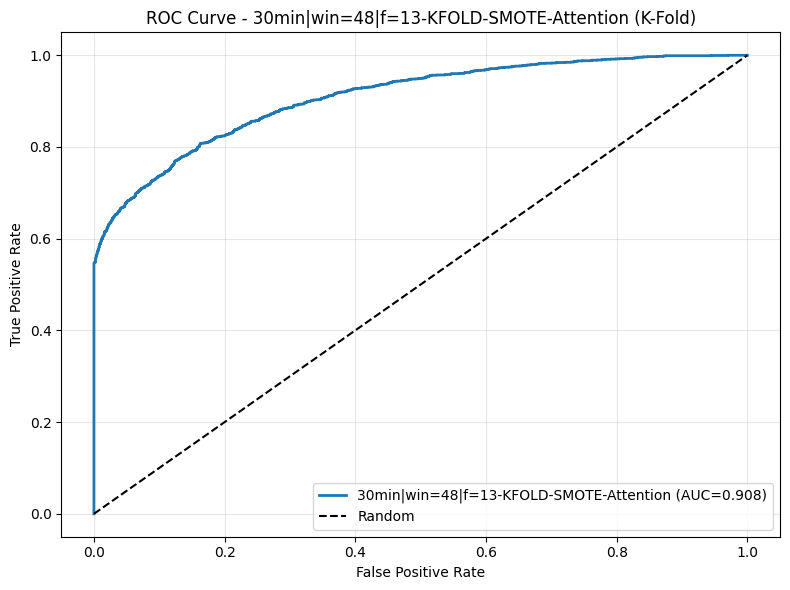

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_kfold_attention_30min_win48_f13-KFOLD-SMOTE-Attention.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_kfold_attention_30min_win48_f13-KFOLD-SMOTE-Attention.pkl

📊 FINAL RESULTS (K-Fold Training):
   CV Mean F1:  0.8180 ± 0.0047
   Test F1:     0.8053
   Test AUC:    0.9079
      ✅ Saved K-Fold assets to: ../data/output_kfold\30min_win48_f13-KFOLD-SMOTE-Attention

    🧠 Model Type: BiDirectional-Attention (K-Fold)
      → Running SMOTE...
      → Training with 5-Fold CV...

📊 Data Split (NO VALIDATION SET):
   Train: 16179 samples (80%)
   Test:  4045 samples (20%)
   (Original split was 60/20/20, now 80/20)

🔄 Running 5-Fold Cross Validation...

  📁 Fold 1/5
     Train: 12943, Val: 3236
Training: 12943 samples, 102 batches/epoch, batch_size=128
Validation: 323

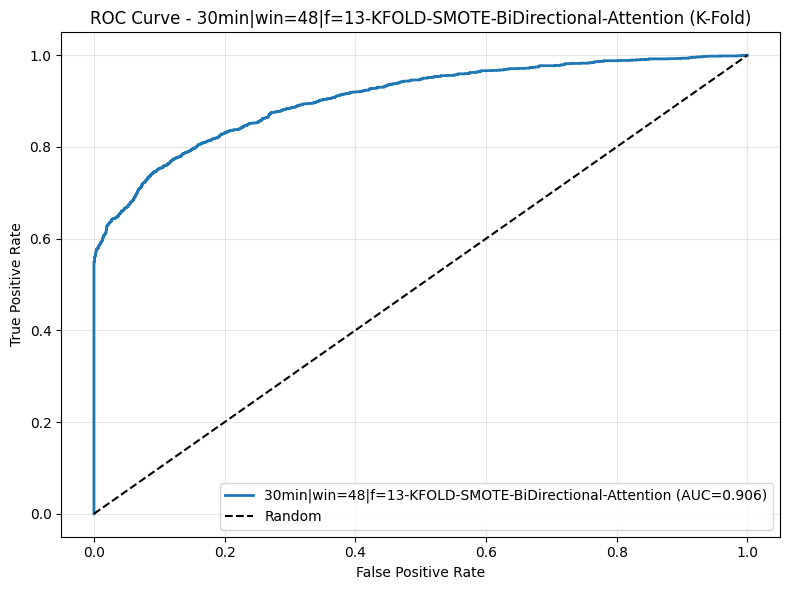

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_kfold_bidirectional-attention_30min_win48_f13-KFOLD-SMOTE-BiDirectional-Attention.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_kfold_bidirectional-attention_30min_win48_f13-KFOLD-SMOTE-BiDirectional-Attention.pkl

📊 FINAL RESULTS (K-Fold Training):
   CV Mean F1:  0.8217 ± 0.0059
   Test F1:     0.8155
   Test AUC:    0.9058
      ✅ Saved K-Fold assets to: ../data/output_kfold\30min_win48_f13-KFOLD-SMOTE-BiDirectional-Attention

✅ K-Fold Experiment completed! Total results: 2


In [8]:
# === 5. Run K-Fold Experiment ===

# Feature Strategy (same as original for comparison)
FEATURE_STRATEGY = 'service_moderate'

FEATURE_STRATEGIES = {
    'baseline': ['Priority', 'Impact'],
    'quick_win': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared'
    ],
    'moderate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos'
    ],
    'service_moderate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'service_risk_score', 'service_frequency'
    ],
}

base_feature_cols = FEATURE_STRATEGIES[FEATURE_STRATEGY]

print(f"\n{'='*60}")
print(f"🎯 K-FOLD EXPERIMENT")
print(f"   Strategy: {FEATURE_STRATEGY}")
print(f"   Features: {len(base_feature_cols)}")
print(f"{'='*60}")

# Enable BiDirectional if needed
ENABLE_BIDIRECTIONAL = True
if ENABLE_BIDIRECTIONAL:
    MODEL_REGISTRY['BiDirectional-Attention'] = BiDirectionalAttentionLSTMModelGPUOptimized

# Configuration
sampling_periods = ['30min']
window_sizes = [48]
model_types = list(MODEL_REGISTRY.keys())
n_folds = 5  # K-Fold parameter

results_all = []

for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    # Aggregation
    agg_dict = {'incident': 'sum'}
    for feature in base_feature_cols:
        if feature in ['hour', 'day_of_week']:
            agg_dict[feature] = 'first'
        else:
            agg_dict[feature] = 'mean'
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg(agg_dict)
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)
    
    feature_cols = base_feature_cols.copy()

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, feature_cols, 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")

        for model_type in model_types:
            print(f"\n    {'='*50}")
            print(f"    🧠 Model Type: {model_type} (K-Fold)")
            print(f"    {'='*50}")

            try:
                # SMOTE
                print(f"      → Running SMOTE...")
                X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
                n_features = len(feature_cols)
                Xs = X_sm.reshape((-1, win, n_features))
                
                label = f"{sp}|win={win}|f={n_features}-KFOLD-SMOTE-{model_type}"
                
                print(f"      → Training with {n_folds}-Fold CV...")
                result = train_eval_kfold(
                    Xs, y_sm, 
                    label=label, 
                    model_type=model_type,
                    n_folds=n_folds,
                    print_every=20
                )
                
                result['feature_strategy'] = FEATURE_STRATEGY
                result['n_features'] = n_features
                
                results_all.append(result)
                save_model_assets(result)
                
            except Exception as e:
                print(f"      ✗ Failed: {e}")
                import traceback
                traceback.print_exc()
                continue

print(f"\n{'='*60}")
print(f"✅ K-Fold Experiment completed! Total results: {len(results_all)}")
print('='*60)

In [9]:
# === 6. Results Comparison ===

res_df = pd.DataFrame(results_all)

print("\n" + "="*90)
print("📊 K-FOLD RESULTS (Sorted by F1-Score)")
print("="*90)

display_cols = ['Model', 'ModelType', 'F1_Score', 'CV_Mean_F1', 'CV_Std_F1', 'Precision', 'Recall', 'AUC']
res_df = res_df.sort_values('F1_Score', ascending=False).reset_index(drop=True)
display(res_df[display_cols].round(4))

# Comparison dengan hasil original
print("\n" + "="*90)
print("📈 PERBANDINGAN DENGAN ORIGINAL (60/20/20 split):")
print("="*90)
print("\nOriginal Results (dari notebook sebelumnya):")
print("   Attention:              F1 = 0.8230")
print("   BiDirectional-Attention: F1 = 0.8210")
print("\nK-Fold Results (80/20 split + 5-fold CV):")
for _, row in res_df.iterrows():
    print(f"   {row['ModelType']}: F1 = {row['F1_Score']:.4f} (CV: {row['CV_Mean_F1']:.4f} ± {row['CV_Std_F1']:.4f})")


📊 K-FOLD RESULTS (Sorted by F1-Score)


,Model,ModelType,F1_Score,CV_Mean_F1,CV_Std_F1,Precision,Recall,AUC
0,30min|win=48|f=13-KFOLD-SMOTE-BiDirectional-At...,BiDirectional-Attention,0.8155,0.8217,0.0059,0.8564,0.7784,0.9058
1,30min|win=48|f=13-KFOLD-SMOTE-Attention,Attention,0.8053,0.8180,0.0047,0.8658,0.7527,0.9079



📈 PERBANDINGAN DENGAN ORIGINAL (60/20/20 split):

Original Results (dari notebook sebelumnya):
   Attention:              F1 = 0.8230
   BiDirectional-Attention: F1 = 0.8210

K-Fold Results (80/20 split + 5-fold CV):
   BiDirectional-Attention: F1 = 0.8155 (CV: 0.8217 ± 0.0059)
   Attention: F1 = 0.8053 (CV: 0.8180 ± 0.0047)


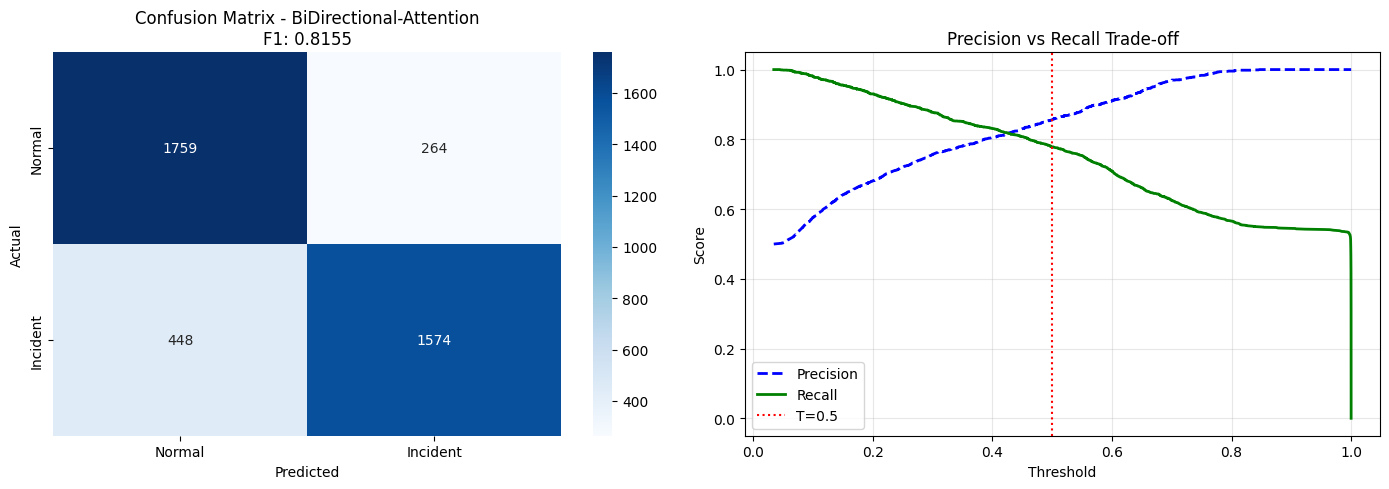


📊 Threshold Sweep:
   T=0.30: F1=0.8123, Precision=0.7562, Recall=0.8773
   T=0.40: F1=0.8177, Precision=0.8050, Recall=0.8309
   T=0.45: F1=0.8190, Precision=0.8306, Recall=0.8076
   T=0.50: F1=0.8155, Precision=0.8564, Recall=0.7784
   T=0.55: F1=0.8130, Precision=0.8825, Recall=0.7537
   T=0.60: F1=0.7973, Precision=0.9105, Recall=0.7092


In [10]:
# === 7. Detailed Analysis ===

# Best model analysis
best = res_df.iloc[0]
y_true = best['y_test']
y_prob = best['y_prob']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
y_pred = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Incident'],
            yticklabels=['Normal', 'Incident'])
axes[0].set_title(f"Confusion Matrix - {best['ModelType']}\nF1: {best['F1_Score']:.4f}")
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Threshold Analysis
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
axes[1].plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
axes[1].plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
axes[1].axvline(x=0.5, color='red', linestyle=':', label='T=0.5')
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision vs Recall Trade-off")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Threshold sweep
print("\n📊 Threshold Sweep:")
for t in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_prob >= t).astype(int)
    f1_t = f1_score(y_true, y_pred_t)
    prec_t = precision_score(y_true, y_pred_t)
    rec_t = recall_score(y_true, y_pred_t)
    print(f"   T={t:.2f}: F1={f1_t:.4f}, Precision={prec_t:.4f}, Recall={rec_t:.4f}")